# **Polynomial Regression and Bias Variance**

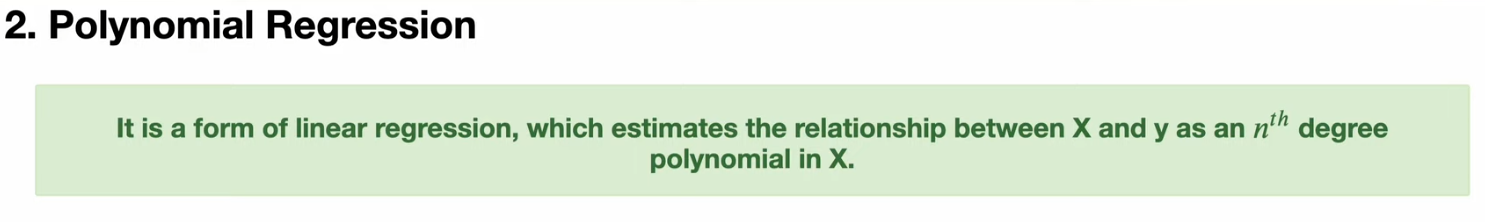

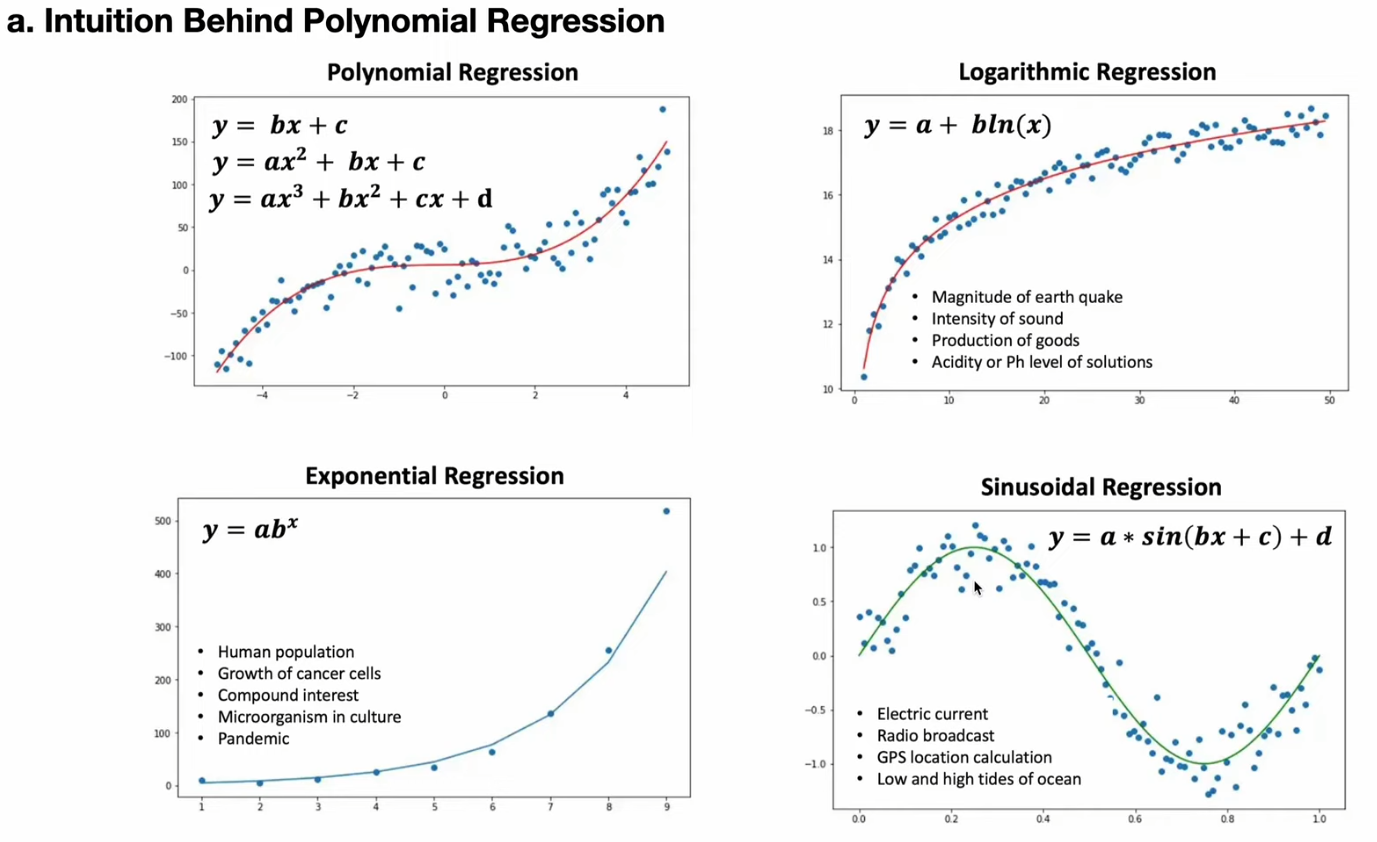

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [73]:
x = df.drop('sales', axis=1)
y = df["sales"]


In [74]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=54)
len(x_train), len(x_test), len(y_train), len(y_test)

(160, 40, 160, 40)

In [75]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [76]:
lr.intercept_, lr.coef_

(np.float64(3.055121653762061), array([ 0.04597903,  0.18579595, -0.0030992 ]))

## **Evalating test Data**

In [77]:
y_predicted = lr.predict(x_test)
test_residuals = y_test - y_predicted
test_residuals

179    0.127337
166   -2.797131
187    0.182347
119   -0.250738
186    0.523071
134   -0.920164
142    0.855536
12    -1.266623
118    0.454900
178   -4.331399
138   -0.180801
43    -1.147050
194    0.766077
11     0.026475
44    -0.349956
101    0.685010
49     1.509119
4     -0.293733
149    0.259924
31     0.540625
188   -2.876221
116    0.167055
33    -1.582141
0      1.656481
181   -1.819920
161   -0.194229
2     -2.859220
183    2.154606
125    1.423384
81    -2.428296
176    0.175563
145    0.468901
124    0.321442
55     2.507281
153    0.809411
137   -0.024063
182    2.093866
156    0.001833
104    0.336298
106    1.043693
Name: sales, dtype: float64

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_predicted)

mse = mean_squared_error(y_test, y_predicted)

rmse = np.sqrt(mse)

r2  = r2_score( y_test, y_predicted )

n = len(x_test)
m = 3

r2_adj = 1 - ((1 - r2) * (n - 1)/ (n - m - 1))

print("MAE: ", mae)
print("MSE: ", mse)
print('RMSE: ', rmse)
print("R2: ", r2)
print("R2_ADJ: ", r2_adj)
print("Mean of Sales Columns: ", df['sales'].mean)



MAE:  1.0602981028984602
MSE:  2.1533134134530876
RMSE:  1.4674172594913444
R2:  0.9175053931302266
R2_ADJ:  0.9106308425577455
Mean of Sales Columns:  <bound method Series.mean of 0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64>


In [79]:
import seaborn as sns

test_residuals = y_test - y_predicted

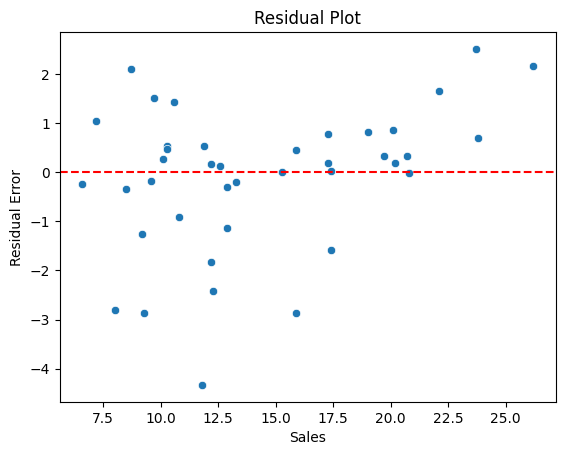

In [80]:

sns.scatterplot(x=y_test, y=test_residuals)

plt.title("Residual Plot")
plt.xlabel("Sales")
plt.ylabel("Residual Error")
plt.axhline(y=0, color = 'r', ls='--')
plt.show()

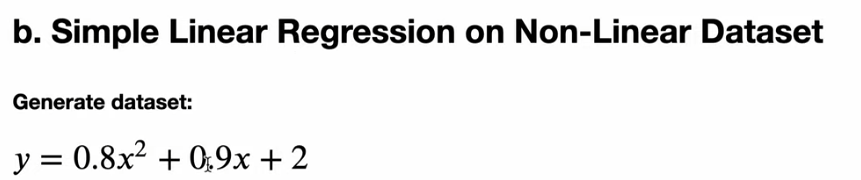

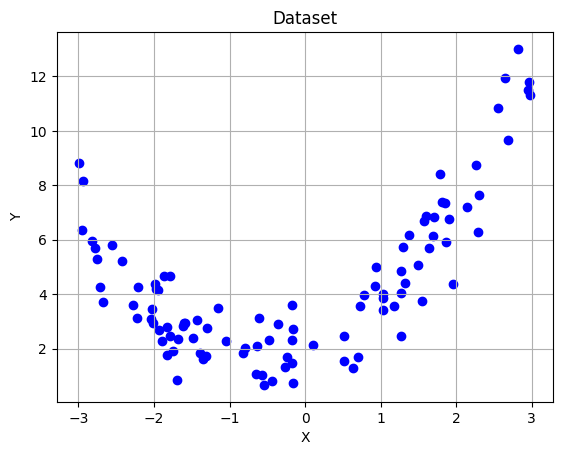

In [81]:
np.random.seed(54)
x = 6 * np.random.rand(100,1) -3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(100,1)

plt.scatter(x, y, color='blue')
plt.title('Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()


In [82]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=54)


In [83]:
lr.fit(x_train, y_train)
lr.intercept_ , lr.coef_

(array([4.52291489]), array([[0.69255604]]))

In [84]:
y_predicted = lr.predict(x_test)

y_predicted.shape, y_test.shape

((20, 1), (20, 1))

In [85]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_predicted)

print("RMSE: ", rmse)
print('R2: ', r2)


RMSE:  2.3563137008458073
R2:  0.41718575401462


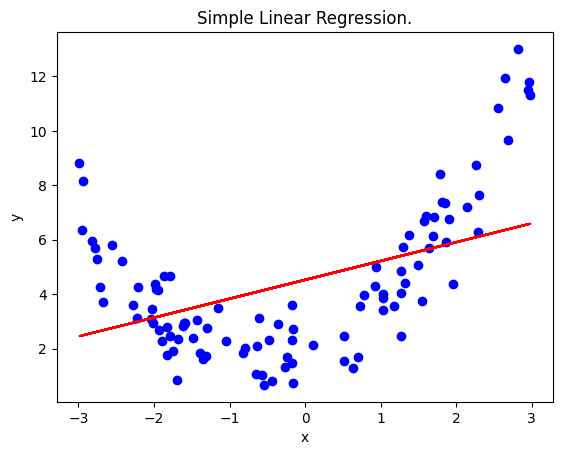

In [86]:
plt.scatter(x,y,color='blue')
plt.plot(x, lr.predict(x), color='r')
plt.title('Simple Linear Regression.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

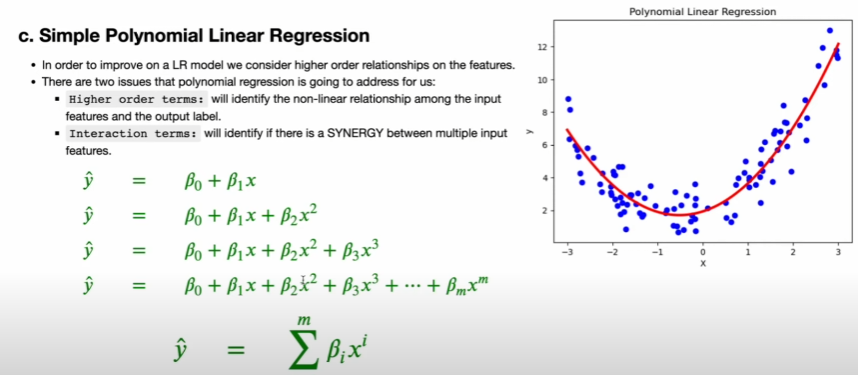

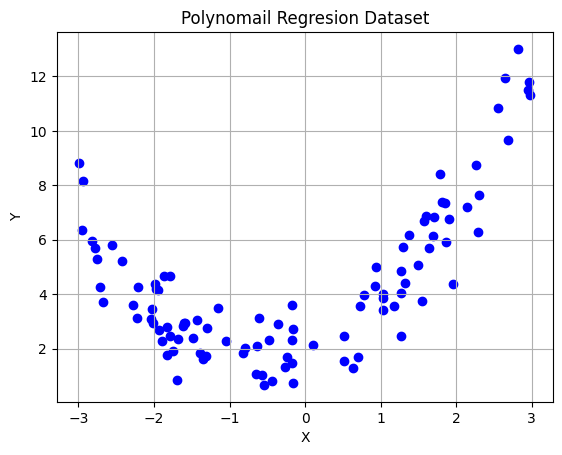

In [87]:
np.random.seed(54)
x = 6 * np.random.rand(100,1) -3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(100,1)

plt.scatter(x, y, color='blue')
plt.title('Polynomail Regresion Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

In [88]:
from sklearn.preprocessing import PolynomialFeatures

poly_tf = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)

In [89]:
poly_feature  = poly_tf.fit_transform(x)

In [90]:
poly_feature.shape

(100, 2)

In [91]:
x[0]

array([-0.4789022])

In [92]:
poly_feature[0]

array([-0.4789022 ,  0.22934731])

In [93]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(poly_feature,y, test_size=0.2, random_state=54)


In [94]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [95]:
lr.fit(x_train, y_train)

LinearRegression()

In [96]:
lr.intercept_, lr.coef_

(array([1.92540845]), array([[0.87609787, 0.84623229]]))

In [97]:
y_predicted = lr.predict(x_test)
y_predicted.shape, y_test.shape

((20, 1), (20, 1))

In [98]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_predicted)

print("RMSE: ", rmse)
print('R2: ', r2)

RMSE:  1.1049482986734125
R2:  0.8718413697606255


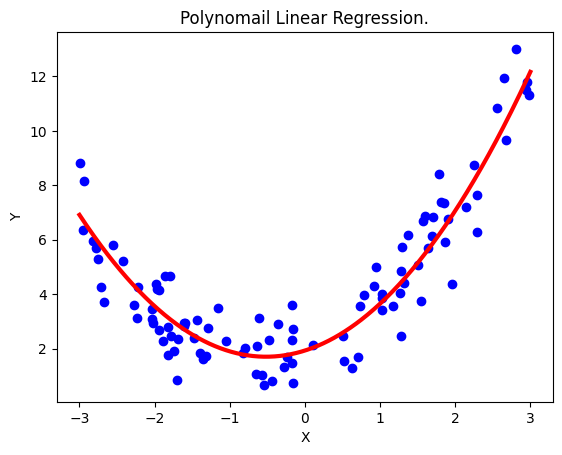

In [99]:
plt.scatter(x,y,color='blue')
# x_new = np.linspace(x_train.min(), x_train.max(), 500).reshape(500, 1)
x_new = np.linspace(-3, 3, 500).reshape(500, 1)
x_new_poly = poly_tf.transform(x_new)
y_new = lr.predict(x_new_poly)
plt.plot(x_new, y_new, linewidth=3, color='red')

plt.title('Polynomail Linear Regression.')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

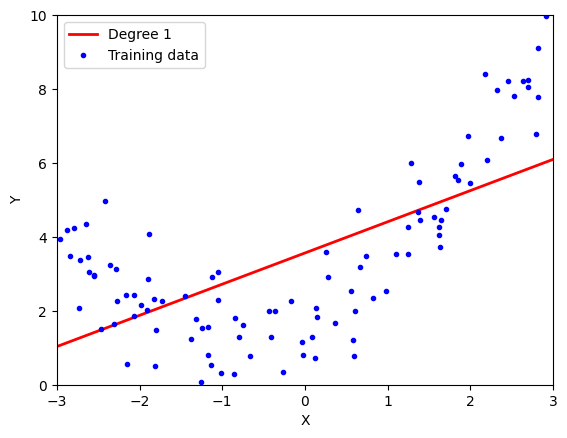

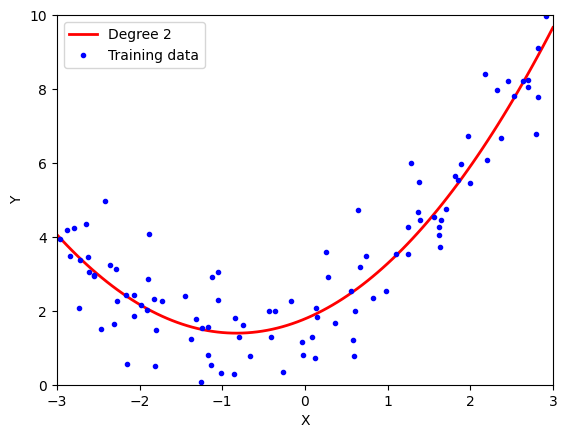

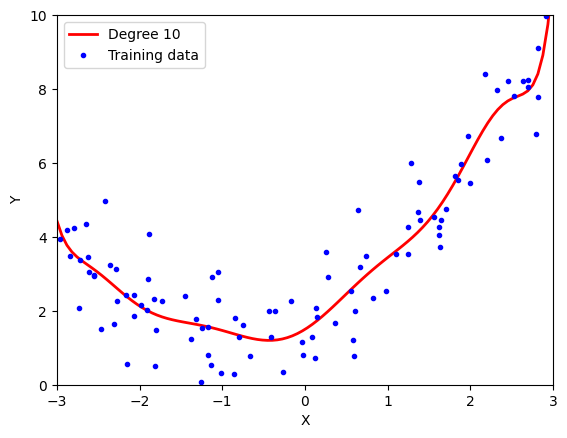

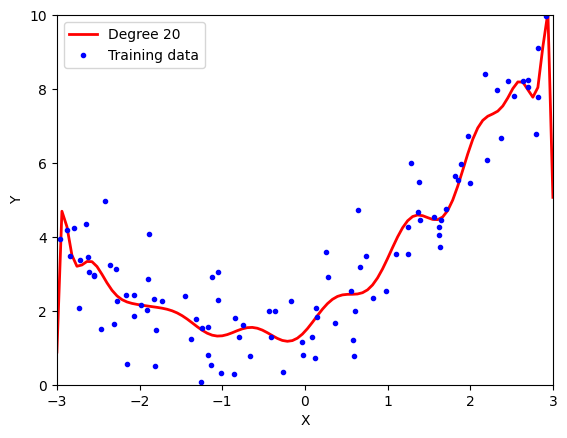

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()

    polynomial_regression_pipeline = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg),
    ])

    np.random.seed(42)
    m = 100
    X = 6 * np.random.rand(m, 1) - 3
    y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

    polynomial_regression_pipeline.fit(X, y)
    y_newbig = polynomial_regression_pipeline.predict(X_new)

    plt.plot(X_new, y_newbig, 'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X, y, "b.", label="Training data", linewidth=3) # Changed label to be more descriptive
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

polynomial_regression(degree=1)
polynomial_regression(degree=2)
polynomial_regression(degree=10)
polynomial_regression(degree=20)

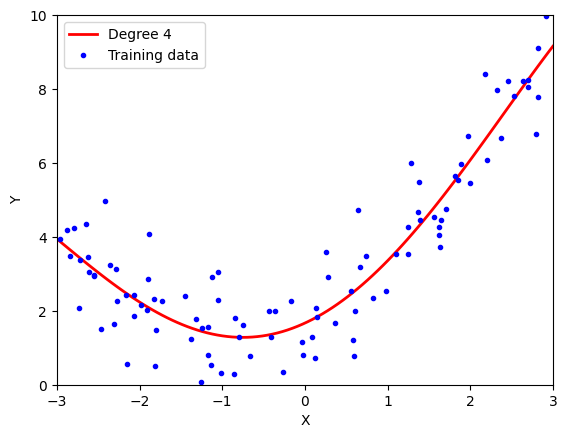

In [ ]:
polynomial_regression(degree=4)

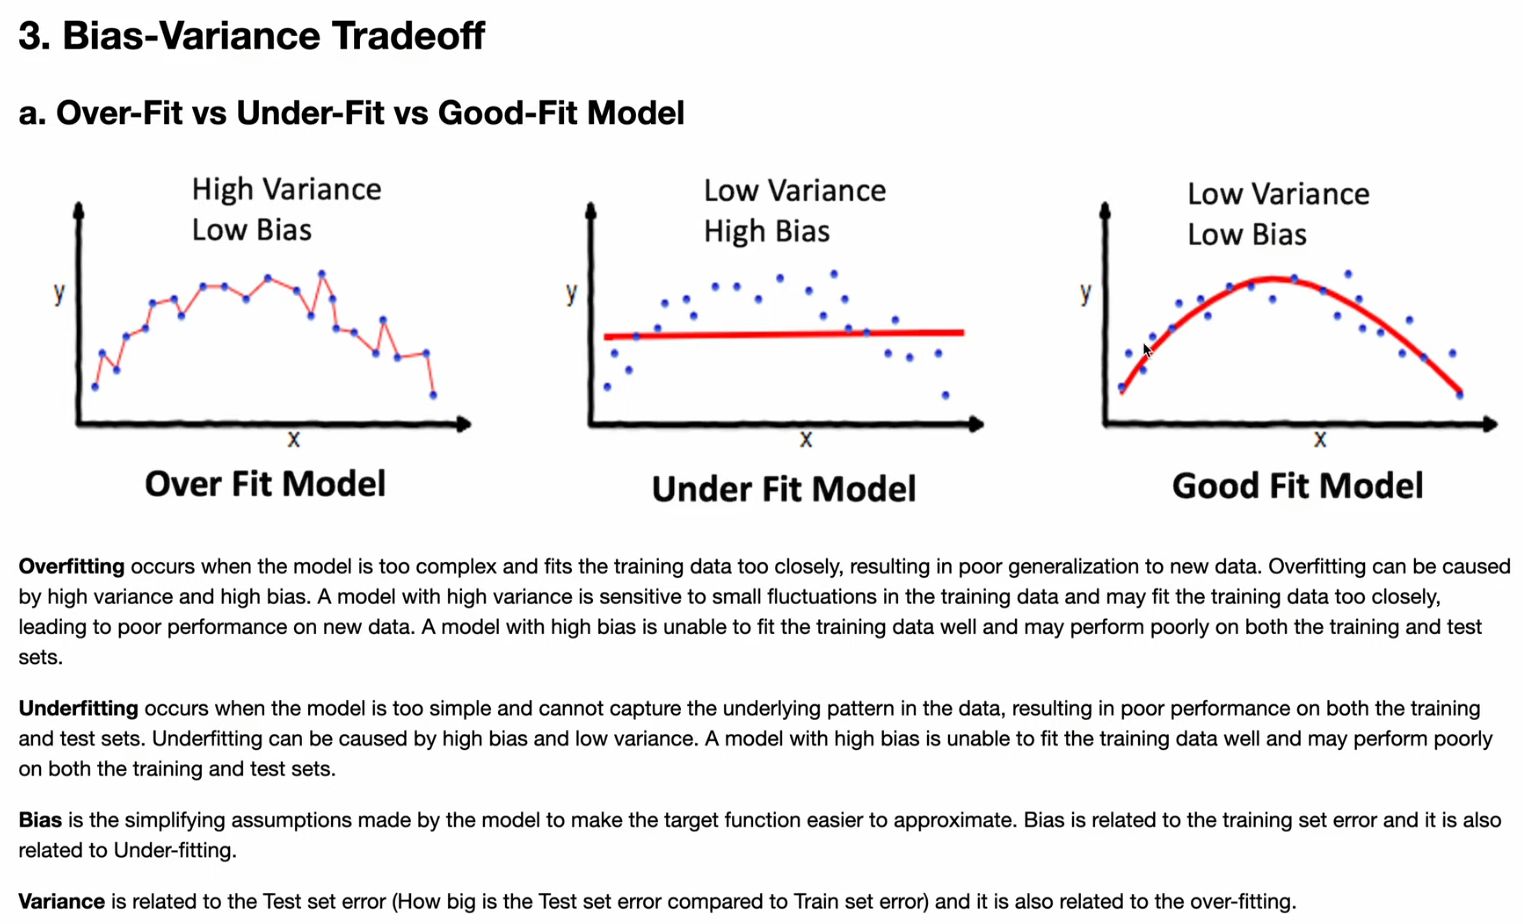

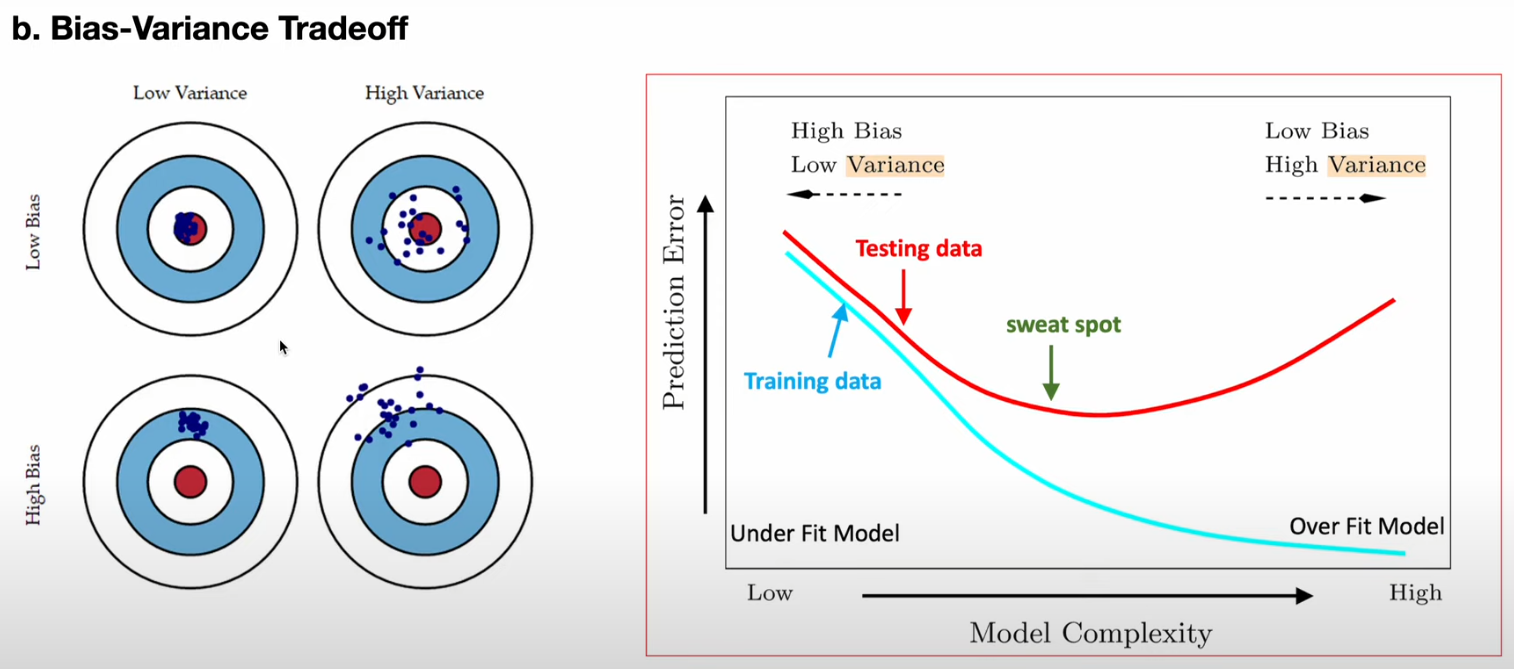

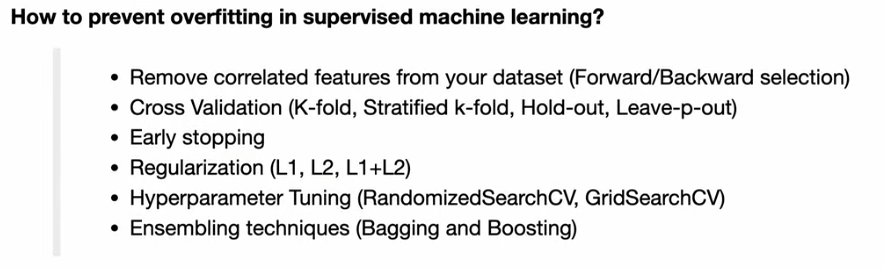

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")
df.head(5)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [2]:
x = df.drop('sales', axis=1)
y = df["sales"]

In [3]:
from sklearn.preprocessing import PolynomialFeatures
poly_tfm = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)


In [4]:
poly_tfm.fit(x)
poly_feature = poly_tfm.transform(x)
print(poly_feature)
print(poly_feature.shape)


[[ 230.1    37.8    69.2  ... 1428.84 2615.76 4788.64]
 [  44.5    39.3    45.1  ... 1544.49 1772.43 2034.01]
 [  17.2    45.9    69.3  ... 2106.81 3180.87 4802.49]
 ...
 [ 177.      9.3     6.4  ...   86.49   59.52   40.96]
 [ 283.6    42.     66.2  ... 1764.   2780.4  4382.44]
 [ 232.1     8.6     8.7  ...   73.96   74.82   75.69]]
(200, 9)


In [8]:
x.iloc[0,:]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [9]:
poly_feature[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(poly_feature, y, test_size=0.2, random_state=54)
print(x_train.shape) 
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 9)
(40, 9)
(160,)
(40,)


In [15]:
from sklearn.linear_model import LinearRegression
poly_lr = LinearRegression()
poly_lr.fit(x_train, y_train)

LinearRegression()

In [16]:
print("Poly_intercept: ", poly_lr.intercept_)
print("Poly_coef: ", poly_lr.coef_)

Poly_intercept:  4.8954504915872405
Poly_coef:  [ 5.45417727e-02  1.94824457e-02  1.03435154e-02 -1.18459276e-04
  1.11189977e-03 -5.60767895e-05  1.71315991e-04 -3.26429330e-05
  7.03414270e-06]


In [17]:
y_predicted = poly_lr.predict(x_test)
test_residuals = y_test - y_predicted

In [18]:
from sklearn.metrics import mean_squared_error as ms, r2_score as r2_

mse = ms(y_test, y_predicted)
rmse = np.sqrt(mse)
r2 = r2_(y_test, y_predicted) 
print("RMSE: ", rmse)
print("R2: ", r2)

RMSE:  0.47720008564499344
R2:  0.9912759260667968
